# 04 — Normalización: números, formato largo y columnas derivadas
Lee los crudos de los pasos 03 y 07 y escribe `data/interim/norm_*.csv`.
- El punto es separador de miles y la coma decimal: "86.285" son 86285 y "70,7%" es 70,7.
- Los porcentajes quedan en unidades de porcentaje, como en el documento.
- Ninguna columna de origen se sobrescribe: lo interpretado va en columnas nuevas.
- Lo que no se puede convertir queda nulo y se registra; nunca se inventa un cero.

In [1]:
%run -i modulos/comun.ipynb
%run -i modulos/geografia.ipynb
%run -i modulos/materias.ipynb
%run -i modulos/juzgados.ipynb
%run -i modulos/procesos.ipynb
%run -i modulos/contexto_procesos.ipynb
%run -i modulos/correcciones_tipo_proceso.ipynb
import matplotlib.pyplot as plt

GESTION = 2023
RE_NUMERICO = re.compile(r"^-?\d[\d.]*(?:,\d+)?%?$")
problemas = []


def anotar(origen, columna, valor, motivo):
    problemas.append({"origen": origen, "columna": columna, "valor_crudo": valor, "motivo": motivo})


def guardar(df, nombre):
    df.to_csv(INTERIM / nombre, index=False, encoding="utf-8")
    print(nombre, len(df), "filas", len(df.columns), "columnas")

## Conversión de texto a número

In [2]:
def texto_a_numero(valor, origen="", columna=""):
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return None
    texto = str(valor).strip()
    if texto == "" or texto.lower() == "nan":
        return None
    if not RE_NUMERICO.match(texto):
        anotar(origen, columna, texto, "no convertible a número; queda nulo")
        return None
    limpio = texto.rstrip("%").replace(".", "").replace(",", ".")
    try:
        numero = float(limpio)
    except ValueError:
        anotar(origen, columna, texto, "no convertible a número; queda nulo")
        return None
    if numero.is_integer() and "," not in texto:
        return int(numero)
    return numero


def tipar(df, columnas, origen):
    # Conteos como Int64 (entero con nulos): un número de juzgados no es 163.0.
    # Si la columna tiene algún decimal, Float64.
    for col in columnas:
        if col not in df.columns:
            continue
        valores = []
        hay_decimal = False
        for v in df[col]:
            numero = texto_a_numero(v, origen, col)
            valores.append(numero)
            if isinstance(numero, float):
                hay_decimal = True
        if hay_decimal:
            df[col] = pd.array(valores, dtype="Float64")
        else:
            df[col] = pd.array(valores, dtype="Int64")
    return df


PREFIJOS_CONTEO = ("pendientes", "ingresadas", "atendidas", "resueltas", "num_", "promedio", "items", "remun",
                   "denuncias", "amonestacion", "multa", "suspension", "destitucion", "total_", "recibidas",
                   "rechazadas", "en_tramite", "resoluciones", "col_sin_rotulo", "valor", "pct_")


def columnas_de_conteo(df):
    salida = []
    for c in df.columns:
        if c.startswith(PREFIJOS_CONTEO):
            salida.append(c)
    return salida


def con_materias(df, columna_etiqueta):
    descripciones = []
    for v in df[columna_etiqueta]:
        descripciones.append(describir_materia(v))
    for clave in ["materia_cruda", "materia_norm", "materia_homologada", "instancia_derivada",
                  "tipo_fila_derivado", "errata_corregida"]:
        valores = []
        for d in descripciones:
            valores.append(d[clave])
        df[clave] = valores
    return df


def trazabilidad(df):
    df["gestion"] = GESTION
    df["revisado_manual"] = False
    return df


def tipos_de_fila(serie):
    salida = []
    for e in serie:
        salida.append(tipo_de_fila(e))
    return salida

## 9.1 — Movimiento de causas
La etiqueta de fila es materia, ciudad o departamento según el cuadro: se abre en columnas separadas.
Las filas de total no son ninguna de las tres.

In [3]:
df = pd.read_csv(INTERIM / "crudo_9_1_movimiento.csv", dtype=str)
df = tipar(df, columnas_de_conteo(df), "9.1.x movimiento")
tipos = tipos_de_fila(df["etiqueta_fila"])
ciudades = []
departamentos = []
for i in range(len(df)):
    e = df["etiqueta_fila"].iloc[i]
    eje = df["eje"].iloc[i]
    if eje == "ciudad" and tipos[i] == "dato":
        ciudades.append(e)
    else:
        ciudades.append(None)
    if eje == "departamento" and tipos[i] == "dato":
        departamentos.append(departamento_normalizado(e))
    else:
        departamentos.append(None)
df["ciudad"] = ciudades
df["departamento"] = departamentos
derivados = []
for c in df["ciudad"]:
    derivados.append(departamento_de_ciudad(c))
df["departamento_derivado"] = derivados
es_materia = (df["eje"] == "materia") & pd.Series([t == "dato" for t in tipos], index=df.index)
df["etiqueta_materia"] = df["etiqueta_fila"].where(es_materia)
df = con_materias(df, "etiqueta_materia")
df = df.drop(columns=["etiqueta_materia"])
df["tipo_fila_derivado"] = tipos
movimiento = trazabilidad(df)
guardar(movimiento, "norm_causas_movimiento.csv")

norm_causas_movimiento.csv 78 filas 26 columnas


## 9.1 — Gestiones e histórico

In [4]:
df = pd.read_csv(INTERIM / "crudo_9_1_gestiones.csv", dtype=str)
df = tipar(df, ["gestion", "resueltas", "pct_resueltas"], "9.1.x gestiones")
df = con_materias(df, "etiqueta_fila")
df["revisado_manual"] = False
guardar(df, "norm_causas_gestiones.csv")

df = pd.read_csv(INTERIM / "crudo_9_1_historico.csv", dtype=str)
df = tipar(df, ["gestion"] + columnas_de_conteo(df), "9.1.x histórico")
df["revisado_manual"] = False
historico = df
guardar(historico, "norm_causas_historico.csv")

norm_causas_gestiones.csv 235 filas 15 columnas
norm_causas_historico.csv 51 filas 17 columnas


## 13.1 — Autoridad sumariante; 14.1 — Personal

In [5]:
df = pd.read_csv(INTERIM / "crudo_13_1_sumariante.csv", dtype=str)
df = tipar(df, columnas_de_conteo(df), "13.1.x")
df["distrito"] = df["etiqueta_fila"].where(df["eje"] == "distrito")
df["ente"] = df["etiqueta_fila"].where(df["eje"] == "ente")
derivados = []
for d in df["distrito"]:
    if isinstance(d, str):
        derivados.append(departamento_de_distrito(d))
    else:
        derivados.append(None)
df["departamento_derivado"] = derivados
df["tipo_fila_derivado"] = tipos_de_fila(df["etiqueta_fila"])
guardar(trazabilidad(df), "norm_sumariante.csv")

norm_sumariante.csv 27 filas 21 columnas


In [6]:
df = pd.read_csv(INTERIM / "crudo_14_1_personal.csv", dtype=str)
df = tipar(df, columnas_de_conteo(df), "14.1.x")
derivados = []
for d in df["distrito"]:
    if isinstance(d, str):
        derivados.append(departamento_de_distrito(d))
    else:
        derivados.append(None)
df["departamento_derivado"] = derivados
df["tipo_fila_derivado"] = tipos_de_fila(df["ente"].fillna(df["distrito"]))
guardar(trazabilidad(df), "norm_personal.csv")

df = pd.read_csv(INTERIM / "crudo_p746_jurisdiccional_administrativo.csv", dtype=str)
df = tipar(df, ["items", "items_pct", "remuneracion", "remuneracion_pct"], "p746")
df["tipo_fila_derivado"] = tipos_de_fila(df["personal"])
guardar(trazabilidad(df), "norm_personal_jurisdiccional.csv")

norm_personal.csv 85 filas 17 columnas
norm_personal_jurisdiccional.csv 3 filas 11 columnas


## 4.1 — Juzgados a formato largo: una fila por (cuadro, rótulo, columna)
Se agrega la semántica auditada de cada columna y, en el 4.1.1, de sus 37 filas y su jerarquía.

In [7]:
ancho = pd.read_csv(INTERIM / "crudo_4_1_juzgados.csv", dtype=str)
heads = pd.read_csv(INTERIM / "columnas_4_1_encabezados.csv", dtype=str)
mapa_head = {}
for i, r in heads.iterrows():
    mapa_head[(r["cuadro_origen"], r["columna"])] = r["fragmentos_encabezado"]

# Hay rótulos repetidos (dos filas "Penal" en el 4.1.1): se numera la fila dentro del cuadro.
ancho.insert(0, "fila_en_cuadro", ancho.groupby("cuadro_origen").cumcount() + 1)
cols_valor = []
cols_id = []
for c in ancho.columns:
    if c.startswith("col_"):
        cols_valor.append(c)
    else:
        cols_id.append(c)
cols_valor.sort()
largo = ancho.melt(id_vars=cols_id, value_vars=cols_valor, var_name="columna", value_name="valor")
largo = largo[largo["valor"].notna()].copy()
numeros = []
for v in largo["valor"]:
    numeros.append(texto_a_numero(v, "4.1.x", "valor"))
largo["valor"] = numeros

fragmentos = []
ultima = []
for c, col, n in zip(largo["cuadro_origen"], largo["columna"], largo["n_columnas"]):
    fragmentos.append(mapa_head.get((c, col)))
    ultima.append(col == "col_" + str(int(n)).zfill(2))
largo["fragmentos_encabezado"] = fragmentos
largo["es_ultima_columna"] = ultima
largo = largo.rename(columns={"rotulo_1": "provincia_o_grupo", "rotulo_2": "localidad_o_subtipo"})

In [8]:
desc_columna = []
faltantes = set()
for cuadro, columna in zip(largo["cuadro_origen"], largo["columna"]):
    d = describir_columna_juzgado(cuadro, columna)
    desc_columna.append(d)
    if d is None:
        faltantes.add((cuadro, columna))
if len(faltantes) > 0:
    raise ValueError("Combinaciones de juzgados sin auditoría aprobada: " + str(sorted(faltantes)))


def valor_o_na(valor):
    if valor is None:
        return pd.NA
    return valor


largo["columna_rotulo_canonico"] = [valor_o_na(d["rotulo_canonico"]) for d in desc_columna]
largo["columna_codigo_canonico"] = [valor_o_na(d["codigo_canonico"]) for d in desc_columna]
largo["tipo_columna"] = [d["tipo_columna"] for d in desc_columna]

desc_fila = []
inesperados = set()
for cuadro, fila, literal in zip(largo["cuadro_origen"], largo["fila_en_cuadro"], largo["provincia_o_grupo"]):
    d = describir_fila_4_1_1(cuadro, fila)
    desc_fila.append(d)
    if cuadro == "4.1.1":
        if d is None:
            inesperados.add((int(fila), literal, None))
        elif literal != d["literal_original"]:
            inesperados.add((int(fila), literal, d["literal_original"]))
if len(inesperados) > 0:
    raise ValueError("Las filas de 4.1.1 no coinciden con la auditoría aprobada: " + str(sorted(inesperados)))

destinos = {"fila_id": "fila_id", "rotulo_canonico": "fila_rotulo_canonico", "codigo_canonico": "fila_codigo_canonico",
            "tipo_entidad": "tipo_entidad", "estructura": "estructura_fila", "fila_padre_id": "fila_padre_id"}
for campo in destinos:
    valores = []
    for d in desc_fila:
        if d is not None and d[campo] is not None:
            valores.append(d[campo])
        else:
            valores.append(pd.NA)
    largo[destinos[campo]] = valores
niveles = []
hojas = []
for d in desc_fila:
    if d is None:
        niveles.append(pd.NA)
        hojas.append(pd.NA)
    else:
        niveles.append(d["nivel_jerarquia"])
        hojas.append(d["estructura"] == "detalle")
largo["nivel_jerarquia"] = pd.array(niveles, dtype="Int64")
largo["es_hoja_jerarquia"] = pd.array(hojas, dtype="boolean")
largo["departamento_derivado"] = [departamento_normalizado(d) for d in largo["departamento"]]
juzgados_largo = trazabilidad(largo)
guardar(juzgados_largo, "norm_juzgados.csv")

norm_juzgados.csv 1148 filas 26 columnas


## Capítulos 5 y 6 — por tipo de proceso
- La materia sale de la sección del cuadro; en penal se afina con el tipo de acción penal.
- El grupo de proceso (texto rotado, llega partido) se resuelve contra la lista cerrada.
- Se agregan el contexto auditado (etapa, acción penal) y las 87 correcciones de rótulo.
- Causas queda ancha (comparte vocabulario de columnas); las otras cuatro familias pasan a
  formato largo: cada valor viaja con el nombre de su columna y el rótulo literal del PDF.

In [9]:
METADATOS_PROCESOS = ["cuadro_origen", "firma", "familia", "ambito", "titulo_pagina", "entidad", "unidad_fila",
                      "grupo_proceso", "tipo_proceso_extraido", "tipo_proceso", "tipo_fila_derivado",
                      "pagina_pdf", "num_juzgados_pagina", "orden_fila", "n_columnas"]
TABLA_DE_FAMILIA = {"causas": "causas_por_tipo_proceso", "resueltas": "resueltas_por_tipo_proceso",
                    "apelacion": "apelaciones_por_tipo_proceso", "ejecucion": "ejecucion_por_tipo_proceso",
                    "otros": "otros_tramites_por_tipo_proceso"}

firmas = pd.read_csv(INTERIM / "firmas_procesos.csv")
rotulo_pdf = {}
for i, r in firmas.iterrows():
    rotulo_pdf[(r["firma"], r["columna"])] = r["encabezado_pdf"]


def a_formato_largo(df, valores):
    orden = {}
    for firma in df["firma"].unique():
        columnas = LAYOUTS_PROCESOS[firma]["columnas"]
        for i in range(len(columnas)):
            orden[(firma, columnas[i])] = i + 1
    meta = []
    for c in df.columns:
        if c not in valores:
            meta.append(c)
    largo = df.melt(id_vars=meta, value_vars=valores, var_name="columna", value_name="valor")
    largo = largo[largo["valor"].notna()].copy()
    largo["orden_columna"] = [orden.get((f, c)) for f, c in zip(largo["firma"], largo["columna"])]
    largo = largo[largo["orden_columna"].notna()]
    largo["rotulo_columna_pdf"] = [rotulo_pdf.get((f, int(o))) for f, o in zip(largo["firma"], largo["orden_columna"])]
    largo["orden_columna"] = largo["orden_columna"].astype(int)
    return largo.sort_values(["pagina_pdf", "orden_fila", "orden_columna"], ignore_index=True)


def normalizar_familia(familia):
    df = pd.read_csv(INTERIM / ("crudo_procesos_" + familia + ".csv"), dtype=str)
    valores = []
    for c in df.columns:
        if c not in METADATOS_PROCESOS:
            valores.append(c)
    df = tipar(df, valores + ["pagina_pdf", "num_juzgados_pagina", "orden_fila", "n_columnas"], "procesos " + familia)

    df["materia_seccion"] = [materia_de_cuadro(c) for c in df["cuadro_origen"]]
    # El tipo de acción penal viene como etiqueta de grupo (5.3.2.1) o como rótulo de fila (5.3.3.1).
    if "grupo_proceso" in df.columns:
        grupo = df["grupo_proceso"]
    else:
        grupo = df["tipo_proceso"]
    tipo = []
    for g, t in zip(grupo, df["tipo_proceso"]):
        sufijo = SUFIJO_PENAL.get(str(g).upper())
        if not sufijo:
            sufijo = SUFIJO_PENAL.get(str(t).upper())
        tipo.append(sufijo)
    df["tipo_accion_penal"] = tipo
    materia_norm = []
    for m, t in zip(df["materia_seccion"], tipo):
        if t:
            materia_norm.append(MATERIA_PENAL.get((m, t), m))
        else:
            materia_norm.append(m)
    df["materia_norm"] = materia_norm
    df["materia_homologada"] = [homologar_materia(m) for m in df["materia_norm"]]
    df["materia_cruda"] = df["titulo_pagina"]

    # La entidad se lee según el ámbito derivado del encabezado de la página, no del número de cuadro.
    es_total = df["entidad"].str.upper().str.startswith("TOTAL").fillna(False)
    df["ciudad"] = df["entidad"].where((df["ambito"] == "capital") & ~es_total)
    df["distrito"] = df["entidad"].where((df["ambito"] == "provincia") & ~es_total)
    df["departamento_derivado"] = [departamento_segun_ambito(a, c, d) for a, c, d in zip(df["ambito"], df["ciudad"], df["distrito"])]
    df["es_total_nacional"] = es_total

    if "grupo_proceso" in df.columns:
        normalizados = []
        sin_mapa = set()
        for g in df["grupo_proceso"]:
            if pd.notna(g):
                n = GRUPOS_PROCESO.get(str(g).strip())
                if n is None:
                    sin_mapa.add(str(g).strip())
            else:
                n = None
            normalizados.append(n)
        df["grupo_proceso_norm"] = normalizados
        for g in sorted(sin_mapa):
            anotar("procesos " + familia, "grupo_proceso", g, "etiqueta de grupo sin entrada en procesos.GRUPOS_PROCESO")

    # Primero el contexto (valida la estructura original) y después las correcciones de rótulo.
    df = incorporar_contexto_procesos(df)
    df = incorporar_correcciones_tipo_proceso(df, TABLA_DE_FAMILIA[familia])
    df = trazabilidad(df)
    if familia == "causas":
        return df
    return a_formato_largo(df, valores)


for familia in ["causas", "resueltas", "apelacion", "ejecucion", "otros"]:
    guardar(normalizar_familia(familia), "norm_procesos_" + familia + ".csv")

norm_procesos_causas.csv 2419 filas 65 columnas


norm_procesos_resueltas.csv 27993 filas 33 columnas


norm_procesos_apelacion.csv 37871 filas 31 columnas


norm_procesos_ejecucion.csv 10015 filas 30 columnas


norm_procesos_otros.csv 6028 filas 33 columnas


## Equivalencias candidatas de materia (para resolver a mano)
No se aplican: la decisión se tomó en la auditoría de materias y está en el módulo materias.
`grupo_sugerido` solo junta textos iguales salvo mayúsculas, tildes y puntuación.

In [10]:
mov = pd.read_csv(INTERIM / "crudo_9_1_movimiento.csv", dtype=str)
ges = pd.read_csv(INTERIM / "crudo_9_1_gestiones.csv", dtype=str)
filas = pd.concat([mov[mov["eje"] == "materia"][["cuadro_origen", "pagina_pdf", "etiqueta_fila"]],
                   ges[["cuadro_origen", "pagina_pdf", "etiqueta_fila"]]])
filas = filas[[tipo_de_fila(e) == "dato" for e in filas["etiqueta_fila"]]]


def clave_texto(texto):
    t = corregir_errata(texto).upper()
    for a, b in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U"), ("Ñ", "N")]:
        t = t.replace(a, b)
    return re.sub(r"[^A-Z]", "", t)


def unir_distintos(serie):
    return " ".join(sorted(set(serie)))


agrupado = filas.groupby("etiqueta_fila").agg(cuadros=("cuadro_origen", unir_distintos),
                                              paginas=("pagina_pdf", unir_distintos)).reset_index()
agrupado = agrupado.rename(columns={"etiqueta_fila": "materia_cruda"})
agrupado["materia_norm"] = [corregir_errata(v) for v in agrupado["materia_cruda"]]
agrupado["clave_texto"] = [clave_texto(v) for v in agrupado["materia_cruda"]]
conteo = agrupado["clave_texto"].value_counts()
sugeridos = []
for k in agrupado["clave_texto"]:
    if conteo[k] > 1:
        sugeridos.append(k)
    else:
        sugeridos.append("")
agrupado["grupo_sugerido"] = sugeridos
agrupado["grupo_manual"] = ""
agrupado = agrupado.drop(columns=["clave_texto"]).sort_values("materia_norm")
guardar(agrupado, "equivalencias_candidatas.csv")

equivalencias_candidatas.csv 31 filas 6 columnas


In [11]:
prob = pd.DataFrame(problemas)
guardar(prob, "problemas_normalizacion.csv")
prob

problemas_normalizacion.csv 0 filas 0 columnas


""


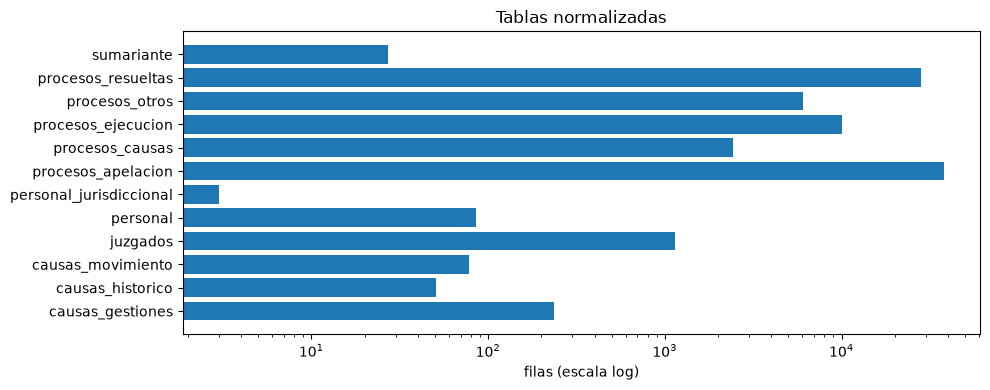

In [12]:
tamanos = []
for f in sorted(INTERIM.glob("norm_*.csv")):
    tamanos.append((f.stem.replace("norm_", ""), len(pd.read_csv(f, usecols=[0]))))
plt.figure(figsize=(10, 4))
plt.barh([t[0] for t in tamanos], [t[1] for t in tamanos], color="tab:blue")
plt.xscale("log")
plt.xlabel("filas (escala log)")
plt.title("Tablas normalizadas")
plt.tight_layout()
plt.show()